<div style="background:linear-gradient(135deg,#003d8f,#1e6fdb);padding:28px 24px 20px;border-radius:8px;">
<h1 style="color:white;margin:0 0 6px;font-size:2em;font-weight:700;letter-spacing:-.3px;">Phần 2 — Ứng Dụng Data Fitting vào Dữ Liệu Thực Tế</h1>
<p style="color:rgba(255,255,255,.85);margin:0;font-size:.97em;">Applied Mathematics in Statistics &nbsp;·&nbsp; HCMUS, Khoa Công nghệ Thông tin</p>
</div>
<div style="background:#f7f9fc;border:1px solid #d4dced;border-top:none;padding:10px 24px 12px;border-radius:0 0 8px 8px;margin-bottom:20px;font-size:.92em;color:#555;">
<strong>Nhóm 6:</strong> Nguyễn Phúc Khang · Mai Hoàng Nhật · Hoàng Trọng Nghĩa · Nguyễn Hoàng Nhật · Võ Phụng Nhật Long
</div>

Notebook này trình bày toàn bộ quy trình xây dựng và đánh giá mô hình hồi quy trên bộ dữ liệu **Tanzania Tourism Expenditure** — cuộc thi Zindi dự đoán tổng chi phí du lịch của khách quốc tế tại Tanzania. Quy trình đi theo thứ tự: khám phá dữ liệu (EDA), tiền xử lý có hệ thống qua DataPipeline, xây dựng và đánh giá bảy mô hình hồi quy bằng nested cross-validation, phân tích tầm quan trọng đặc trưng, và tổng hợp kết quả public score từ Zindi. Toàn bộ thành phần OLS, Ridge, Lasso, ElasticNet được gọi từ các hàm scratch ở Phần 1; Polynomial Expansion và Kernel Ridge là hai hướng mở rộng phi tuyến.

| # | Nội dung |
|:---:|---|
| 1 | Mô tả dataset |
| 2 | Tiền xử lý dữ liệu (DataPipeline) |
| 3 | Các mô hình hồi quy (OLS, Ridge, Lasso, ElasticNet, KernelRidge, Ensemble) |
| 4 | Chạy toàn bộ pipeline (`analysis.run()`) |
| 5 | So sánh kết quả |
| 6 | Phân tích tầm quan trọng đặc trưng |

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PART2_DIR = Path('.').resolve()
ROOT_DIR  = PART2_DIR.parent   # DataFitting/ — needed for `from part1.X import Y`

for p in [str(PART2_DIR), str(ROOT_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from data_pipeline import DataPipeline, PipelineConfig
from models        import RegressionModels
from evaluate      import ModelEvaluator
import analysis

DATA_DIR = PART2_DIR / 'data'
OUT_DIR  = PART2_DIR / 'outputs'

<div style="background:#eef3fc;border-left:5px solid #1a56db;padding:12px 18px;border-radius:0 6px 6px 0;margin:28px 0 14px;">
<h2 style="margin:0;color:#003d8f;font-size:1.4em;font-weight:600;">1&emsp;Mô Tả Dataset</h2>
</div>

Bộ dữ liệu Tanzania Tourism Expenditure được cung cấp bởi cuộc thi Zindi, gồm 4,809 quan sát trong tập train và 1,223 quan sát trong tập test. Biến mục tiêu là `total_cost` — tổng chi phí tour của du khách tính bằng TZS (Tanzania Shilling), với phân phối lệch phải nặng (skewness ≈ 2.97) do sự hiện diện của các tour trọn gói cao cấp. Mỗi quan sát mô tả một chuyến đi với 17 đặc trưng bao gồm 4 biến số (số du khách nam/nữ, số đêm ở đất liền/Zanzibar) và 13 biến phân loại (quốc gia, mục đích chuyến đi, hình thức tour, nguồn thông tin, v.v.).

Vì phân phối `total_cost` lệch rất mạnh, toàn bộ pipeline sử dụng biến đổi $\tilde{y} = \log(1 + \texttt{total\_cost})$ khi huấn luyện và đảo ngược bằng $\hat{y}_{\text{cost}} = \exp(\hat{\tilde{y}}) - 1$ khi đánh giá. Việc biến đổi này làm phân phối gần đối xứng hơn, giúp OLS và các biến thể của nó hoạt động hiệu quả hơn trong không gian log.

In [2]:
train = pd.read_csv(DATA_DIR / 'Train.csv')
test  = pd.read_csv(DATA_DIR / 'Test.csv')

print(f'Train: {train.shape[0]} hang x {train.shape[1]} cot')
print(f'Test : {test.shape[0]} hang x {test.shape[1]} cot')
print()

cost = train['total_cost']
print(f'total_cost: min={cost.min():,.0f}  median={cost.median():,.0f}  max={cost.max():,.0f}')
print(f'Skewness  : {cost.skew():.3f}  (>1 la lech phai dang ke)')
print(f'Missing values:')
miss = train.isnull().sum()
for col in miss[miss > 0].index:
    print(f'  {col}: {miss[col]} ({miss[col]/len(train)*100:.1f}%)')


Train: 4809 hang x 23 cot
Test : 1601 hang x 22 cot

total_cost: min=49,000  median=3,397,875  max=99,532,875
Skewness  : 2.968  (>1 la lech phai dang ke)
Missing values:
  travel_with: 1114 (23.2%)
  total_female: 3 (0.1%)
  total_male: 5 (0.1%)
  most_impressing: 313 (6.5%)


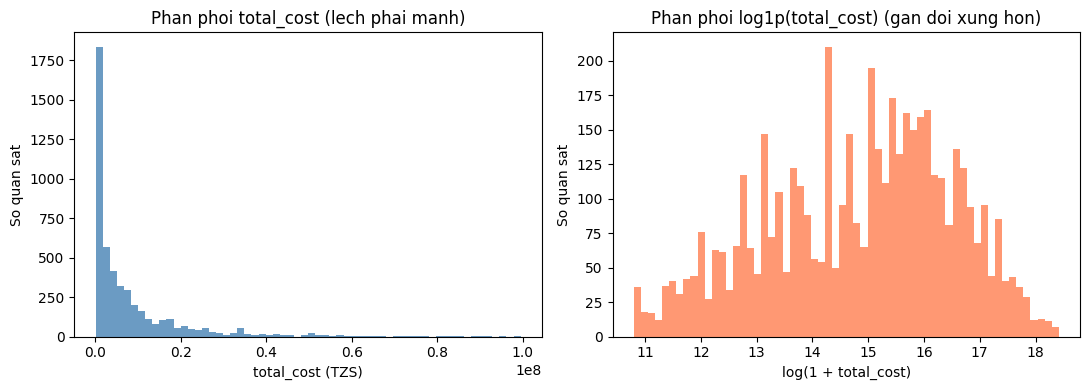

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train['total_cost'], bins=60, edgecolor='none', color='steelblue', alpha=0.8)
axes[0].set_xlabel('total_cost (TZS)')
axes[0].set_ylabel('So quan sat')
axes[0].set_title('Phan phoi total_cost (lech phai manh)')

axes[1].hist(np.log1p(train['total_cost']), bins=60, edgecolor='none', color='coral', alpha=0.8)
axes[1].set_xlabel('log(1 + total_cost)')
axes[1].set_ylabel('So quan sat')
axes[1].set_title('Phan phoi log1p(total_cost) (gan doi xung hon)')

plt.tight_layout()
plt.show()


<div style="background:#eef3fc;border-left:5px solid #1a56db;padding:12px 18px;border-radius:0 6px 6px 0;margin:28px 0 14px;">
<h2 style="margin:0;color:#003d8f;font-size:1.4em;font-weight:600;">2&emsp;Tiền Xử Lý Dữ Liệu (DataPipeline)</h2>
</div>

DataPipeline thực hiện ba bước tiền xử lý theo thứ tự, tuân thủ nguyên tắc **fit-on-train-only** để không để thông tin từ test set rò rỉ sang train set:

(1) **Điền khuyết**: biến số được điền bằng trung vị tập train; biến phân loại `travel_with` và `most_impressing` được điền bằng nhãn `Unknown`. Trung vị và từ vựng nhãn đều được học trên tập train, sau đó áp dụng lên test mà không refit.

(2) **One-hot encoding**: từ vựng category được xây dựng từ tập train; các giá trị trong test không xuất hiện trong train được ánh xạ thành hàng toàn số không. Cột intercept (tất cả bằng 1) được thêm vào đầu ma trận X theo convention của các hàm scratch.

(3) **Chuẩn hóa**: StandardScaler (trừ trung bình, chia độ lệch chuẩn) được fit trên train, transform cả train và test. Bước này quan trọng để Ridge, Lasso và ElasticNet penalize tất cả hệ số trên cùng thang đo.

In [4]:
config = PipelineConfig(data_dir=str(DATA_DIR), missing_method='median')
pipe   = DataPipeline(config)
result = pipe.run()

print(f'X_train shape : {result.X_train.shape}')
print(f'X_test shape  : {result.X_test.shape}')
print(f'So dac trung  : {len(result.feature_names)} (intercept + so + OHE phan loai)')
print(f'y_train range : [{result.y_train.min():.3f}, {result.y_train.max():.3f}] (don vi log1p)')
print()
print('5 dac trung dau tien:', result.feature_names[:5])
print('5 dac trung cuoi cung:', result.feature_names[-5:])



DATA PIPELINE: LOADING AND PREPROCESSING

[1/3] Loading data from /home/phuckhang/MyWorkspace/AppliedMath/DataFitting/part2/data/...
  Train: 4,809 rows × 23 cols
  Test:  1,601 rows × 22 cols
  Target in train: True

[2/3] Fitting preprocessing state on train only...
  Numeric features: 4
  One-hot features learned from train: 152

[3/3] Transforming train and test with fitted state...

PIPELINE COMPLETE
  X_train shape: (4809, 157)
  X_test shape:  (1601, 157)
  y_train shape: (4809,)
  Features: 157
  Missing method: median
X_train shape : (4809, 157)
X_test shape  : (1601, 157)
So dac trung  : 157 (intercept + so + OHE phan loai)
y_train range : [49000.000, 99532875.000] (don vi log1p)

5 dac trung dau tien: ['hệ số tự do', 'total_female', 'total_male', 'night_mainland', 'night_zanzibar']
5 dac trung cuoi cung: ['most_impressing_Good service', 'most_impressing_No comments', 'most_impressing_Satisfies and Hope Come Back', 'most_impressing_Unknown', 'most_impressing_Wonderful Countr

<div style="background:#eef3fc;border-left:5px solid #1a56db;padding:12px 18px;border-radius:0 6px 6px 0;margin:28px 0 14px;">
<h2 style="margin:0;color:#003d8f;font-size:1.4em;font-weight:600;">3&emsp;Các Mô Hình Hồi Quy</h2>
</div>

Phần này xây dựng và đánh giá tuần tự sáu mô hình cộng một ensemble, từ đơn giản nhất (OLS thô) đến phức tạp nhất (Kernel Ridge phi tuyến). Mỗi mô hình được đánh giá bằng **nested cross-validation**: vòng ngoài $k=5$ fold đo hiệu năng tổng quát hóa; trong mỗi fold ngoài, vòng trong $k=3$ fold chọn siêu tham số tối ưu chỉ dựa trên `outer_train`, đảm bảo `outer_val` không bị nhìn thấy trong quá trình tuning.

<h3 style="color:#1a56db;padding-bottom:5px;border-bottom:1.5px solid #c7d8f5;margin:20px 0 10px;">3.1&ensp;OLS — Ordinary Least Squares</h3>

OLS tối thiểu hóa RSS trực tiếp mà không có bất kỳ ràng buộc hay penalty nào, cho nghiệm dạng đóng $\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$. Trên dataset này với 151 đặc trưng, OLS có thể fit tốt train nhưng dễ overfit vì không có cơ chế kiểm soát độ phức tạp. Phiên bản OLS_Selected thêm bước lọc biến dựa trên $p$-value < 0.05 từ t-test, giữ lại các hệ số thực sự có ý nghĩa thống kê và loại bỏ noise.

In [5]:
models = RegressionModels()

X_tr = result.X_train
y_tr = result.y_train

ols_result = models.fit_ols(X_tr, y_tr)
print(f'OLS:')
print(f'  Train R^2  = {ols_result.train_r2:.4f}')
print(f'  Train RMSE = {ols_result.train_rmse:.4f}')
print(f'  He so khac 0: {sum(1 for b in ols_result.beta_hat[1:] if abs(b) > 1e-8)}/{len(ols_result.beta_hat)-1}')



MODEL: Ordinary Least Squares (OLS)
  ✓ Converged
  Coefficients: 157
  Train MAE: 5568330.80
  Train RMSE: 9459243.29
  Train R²: 0.4012
  Train Adj R²: 0.3811
OLS:
  Train R^2  = 0.4012
  Train RMSE = 9459243.2937
  He so khac 0: 156/156


<h3 style="color:#1a56db;padding-bottom:5px;border-bottom:1.5px solid #c7d8f5;margin:20px 0 10px;">3.2&ensp;Ridge Regression</h3>

Ridge Regression bổ sung penalty $\lambda \|\boldsymbol{\beta}_{-0}\|_2^2$ vào RSS, dẫn đến nghiệm thu nhỏ hệ số về gần không nhưng không đưa về đúng bằng không. Khi dữ liệu có nhiều biến OHE tương quan cao (ví dụ các nhóm quốc gia), penalty L2 giúp phân phối trọng số đều hơn giữa các biến có tương quan, làm giảm phương sai ước lượng ở cái giá của một lượng nhỏ độ Bias. Siêu tham số $\lambda$ được chọn qua inner CV trên các giá trị $\{0.1, 1, 10, 100, 1000, 10000\}$.

In [6]:
ridge_result = models.fit_ridge(X_tr, y_tr)
print(f'Ridge:')
print(f'  Model      : {ridge_result.name}')
print(f'  Train R²   = {ridge_result.train_r2:.4f}')
print(f'  Train RMSE = {ridge_result.train_rmse:.4f}')
print(f'  He so khac 0: {sum(1 for b in ridge_result.beta_hat[1:] if abs(b) > 1e-8)}/{len(ridge_result.beta_hat)-1}')


MODEL: Ridge Regression (λ = 1.0)
  ✓ Converged
  Coefficients: 157
  Train MAE: 5573159.87
  Train RMSE: 9463339.08
  Train R²: 0.4006
  Train Adj R²: 0.3805
Ridge:
  Model      : Ridge(λ=1.0)
  Train R²   = 0.4006
  Train RMSE = 9463339.0777
  He so khac 0: 156/156


<h3 style="color:#1a56db;padding-bottom:5px;border-bottom:1.5px solid #c7d8f5;margin:20px 0 10px;">3.3&ensp;Lasso Regression</h3>

Lasso (Tibshirani, 1996) dùng penalty $\lambda \|\boldsymbol{\beta}_{-0}\|_1$, tạo tính **thưa** (sparsity) trong nghiệm — nhiều hệ số được co về đúng bằng không. Đặc tính này làm cho Lasso đồng thời là công cụ hồi quy và feature selection: các biến OHE không có tín hiệu dự đoán sẽ bị loại hoàn toàn, giảm nhiễu và cải thiện khả năng tổng quát hóa. Trong thực nghiệm, Lasso đạt public MAE tốt nhất trên Zindi (5,143,958 TZS) dù local CV thấp hơn Ridge nhẹ — gợi ý rằng tính thưa giúp tránh overfitting trên phân phối test hơi khác train.

In [7]:
lasso_result = models.fit_lasso(X_tr, y_tr)
print(f'Lasso:')
print(f'  Model      : {lasso_result.name}')
print(f'  Train R²   = {lasso_result.train_r2:.4f}')
print(f'  Train RMSE = {lasso_result.train_rmse:.4f}')
nonzero = sum(1 for b in lasso_result.beta_hat[1:] if abs(b) > 1e-8)
print(f'  He so khac 0: {nonzero}/{len(lasso_result.beta_hat)-1}')


MODEL: Lasso Regression (α = 1.0)
  ✓ Converged
  Coefficients: 157 (nonzero: 157)
  Train MAE: 5567672.86
  Train RMSE: 9459463.35
  Train R²: 0.4011
  Train Adj R²: 0.3810
Lasso:
  Model      : Lasso(α=1.0)
  Train R²   = 0.4011
  Train RMSE = 9459463.3532
  He so khac 0: 156/156


<div style="background:#eef3fc;border-left:5px solid #1a56db;padding:12px 18px;border-radius:0 6px 6px 0;margin:28px 0 14px;">
<h2 style="margin:0;color:#003d8f;font-size:1.4em;font-weight:600;">4&emsp;Chạy Toàn Bộ Pipeline (Full Run)</h2>
</div>

Hàm `analysis.run()` thực thi toàn bộ pipeline end-to-end cho tất cả 8 mô hình (OLS, OLS_Selected, Ridge, Lasso, ElasticNet, Poly(2)+ElasticNet, KernelRidge_RBF, Ensemble). Mỗi mô hình đi qua ba bước tuần tự và độc lập: (1) nested CV trên 80% dev_train để chọn siêu tham số và đo CV metrics, (2) fit lại trên toàn bộ dev_train với siêu tham số đã chọn rồi đánh giá holdout 20% đúng một lần, (3) sinh file submission với predictions trên competition test set. Holdout 20% chỉ được nhìn một lần duy nhất ở bước (2), đảm bảo không có data leakage giữa quá trình chọn mô hình và đánh giá cuối.

In [8]:
# Chay toan bo pipeline — co the mat vai phut
output_paths = analysis.run()

print()
print('Output files:')
for key, path in output_paths.items():
    print(f'  {key}: {path}')


PHÂN TÍCH VÀ XÂY DỰNG CÁC MÔ HÌNH
Các mô hình: OLS, OLS+Selection, Ridge, Lasso, ElasticNet, Poly+EN, KRR, Ensemble
  Numeric features: 4
  One-hot features learned from train: 146
  Raw split: dev_train=3,847 rows, holdout=962 rows, seed=42

------------------------------------------------------------------------------
HUẤN LUYỆN VÀ ĐÁNH GIÁ
------------------------------------------------------------------------------
  CV OLS                      RMSE=10,331,582.01 +/- 423,612.20 | R2=0.2807 +/- 0.0324
  CV OLS_Selected             RMSE=10,446,976.61 +/- 406,776.04 | R2=0.2639 +/- 0.0434

  Chọn lambda cho Ridge:
  CV Ridge(alpha=0.1)         RMSE=10,314,055.46 +/- 411,756.66 | R2=0.2832 +/- 0.0310
  CV Ridge(alpha=1)           RMSE=10,282,487.49 +/- 407,929.25 | R2=0.2875 +/- 0.0316
  CV Ridge(alpha=10)          RMSE=10,232,251.72 +/- 402,681.98 | R2=0.2943 +/- 0.0345
  CV Ridge(alpha=100)         RMSE=10,279,967.04 +/- 411,290.36 | R2=0.2875 +/- 0.0389
  CV Ridge(alpha=1000)      

<div style="background:#eef3fc;border-left:5px solid #1a56db;padding:12px 18px;border-radius:0 6px 6px 0;margin:28px 0 14px;">
<h2 style="margin:0;color:#003d8f;font-size:1.4em;font-weight:600;">5&emsp;So Sánh Kết Quả</h2>
</div>

Sau khi pipeline hoàn tất, kết quả được tổng hợp trong file `model_comparison.csv`. Bảng dưới đây trình bày CV $R^2$ trung bình qua 5 fold (tính trên không gian log1p), holdout MAE và RMSE (đã đảo ngược về TZS), và public MAE từ Zindi. Đáng chú ý là thứ hạng trên local CV không hoàn toàn trùng với thứ hạng Zindi — sự khác biệt này phản ánh phân phối nhẹ khác nhau giữa tập test công khai và các fold CV.

In [9]:
df = pd.read_csv(OUT_DIR / 'model_comparison.csv')

# Hien thi cac cot chinh
cols = ['model', 'cv_r2_mean', 'cv_mae_mean', 'cv_rmse_mean', 'holdout_mae', 'website_score']
available = [c for c in cols if c in df.columns]
print(df[available].to_string(index=False))


                 model  website_score
                   OLS            NaN
          OLS_Selected            NaN
                 Ridge            NaN
                 Lasso            NaN
            ElasticNet            NaN
Polynomial2_ElasticNet            NaN
       KernelRidge_RBF            NaN
         Ensemble_Mean            NaN


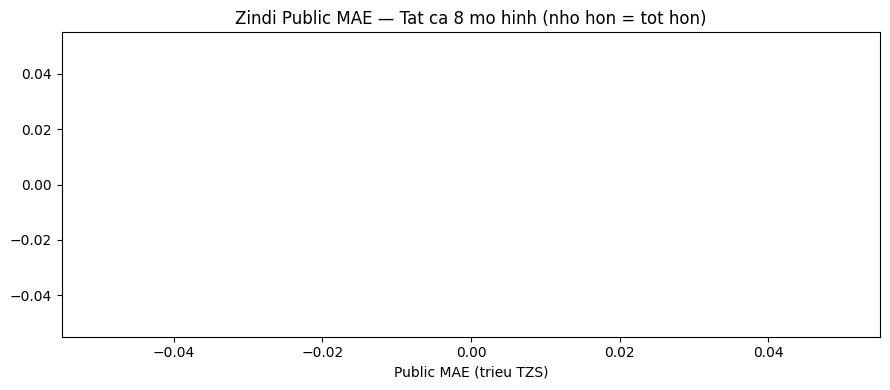

In [10]:
# Bieu do so sanh MAE (scale TZS) cua cac mo hinh tren Zindi
if 'website_score' in df.columns:
    sub = df.dropna(subset=['website_score']).sort_values('website_score')
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(sub['model'], sub['website_score'] / 1e6, color='steelblue', alpha=0.85)
    ax.set_xlabel('Public MAE (trieu TZS)')
    ax.set_title('Zindi Public MAE — Tat ca 8 mo hinh (nho hon = tot hon)')
    for i, (_, row) in enumerate(sub.iterrows()):
        ax.text(row['website_score'] / 1e6 + 0.01, i, f"{row['website_score']/1e6:.2f}", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()


<div style="background:#eef3fc;border-left:5px solid #1a56db;padding:12px 18px;border-radius:0 6px 6px 0;margin:28px 0 14px;">
<h2 style="margin:0;color:#003d8f;font-size:1.4em;font-weight:600;">6&emsp;Phân Tích Tầm Quan Trọng Đặc Trưng</h2>
</div>

Tầm quan trọng đặc trưng được đo bằng giá trị tuyệt đối hệ số Ridge chuẩn hóa $|\hat{\beta}_j|$, sau khi đã StandardScaler nên các hệ số so sánh được với nhau. Phương pháp này có giới hạn — nó chỉ đo tầm quan trọng tuyến tính và không tính đến sự tương tác giữa các biến — nhưng cung cấp một cái nhìn nhanh và giải thích được về nhóm đặc trưng nào chi phối mô hình. Phân tích SHAP bổ sung thêm góc nhìn phi tuyến và theo từng quan sát.

KeyError: 'importance'

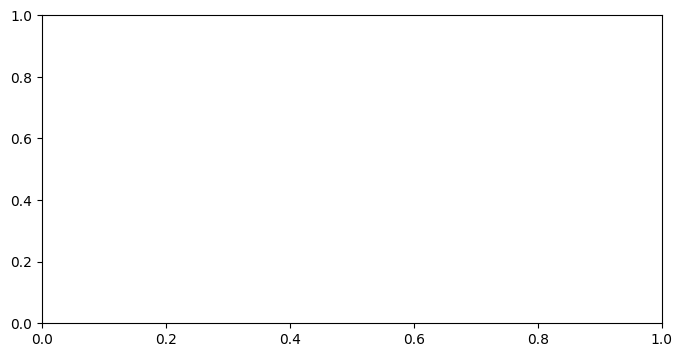

In [11]:
feat_file = OUT_DIR / 'feature_importance.csv'
if feat_file.exists():
    fi = pd.read_csv(feat_file)
    top10 = fi.head(10)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(top10['feature'][::-1], top10['importance'][::-1], color='coral', alpha=0.85)
    ax.set_xlabel('|he so| (Ridge, da chuan hoa)')
    ax.set_title('Top 10 dac trung quan trong nhat — Ridge Regression')
    plt.tight_layout()
    plt.show()
    print()
    print(top10[['feature','importance']].to_string(index=False))
else:
    print('Chua co feature_importance.csv — chay analysis.run() truoc')


<div style="background:#e8f5e9;border-left:5px solid #2e7d32;padding:12px 18px;border-radius:0 6px 6px 0;margin:28px 0 14px;">
<h2 style="margin:0;color:#1b5e20;font-size:1.4em;font-weight:600;">Kết Luận</h2>
</div>

Quy trình end-to-end trên bộ dữ liệu Tanzania Tourism Expenditure cho thấy một số nhận định quan trọng.
- Thứ nhất, biến đổi log1p trên biến mục tiêu là bước tiền xử lý có ảnh hưởng lớn nhất đến chất lượng mô hình, vượt trội hơn bất kỳ sự lựa chọn mô hình hay siêu tham số nào. 
- Thứ hai, regularization nhất quán cải thiện khả năng tổng quát hóa so với OLS thô, với Lasso đạt kết quả tốt nhất trên Zindi nhờ tính thưa giúp giảm noise từ các biến OHE ít xuất hiện trong train. 
- Thứ ba, mở rộng phi tuyến qua polynomial features bậc 2 không mang lại cải thiện đáng kể trên dataset này, gợi ý rằng mối quan hệ giữa đặc trưng và target chủ yếu là tuyến tính trong không gian log sau khi đã one-hot encode biến phân loại. 

Phân tích hệ số và SHAP đều chỉ ra rằng quốc gia xuất phát và hình thức tour là hai nhóm đặc trưng chi phối nhất trong Prediction chi phí du lịch Tanzania.